Simulation Starts with 2 paths. Rate=1.2


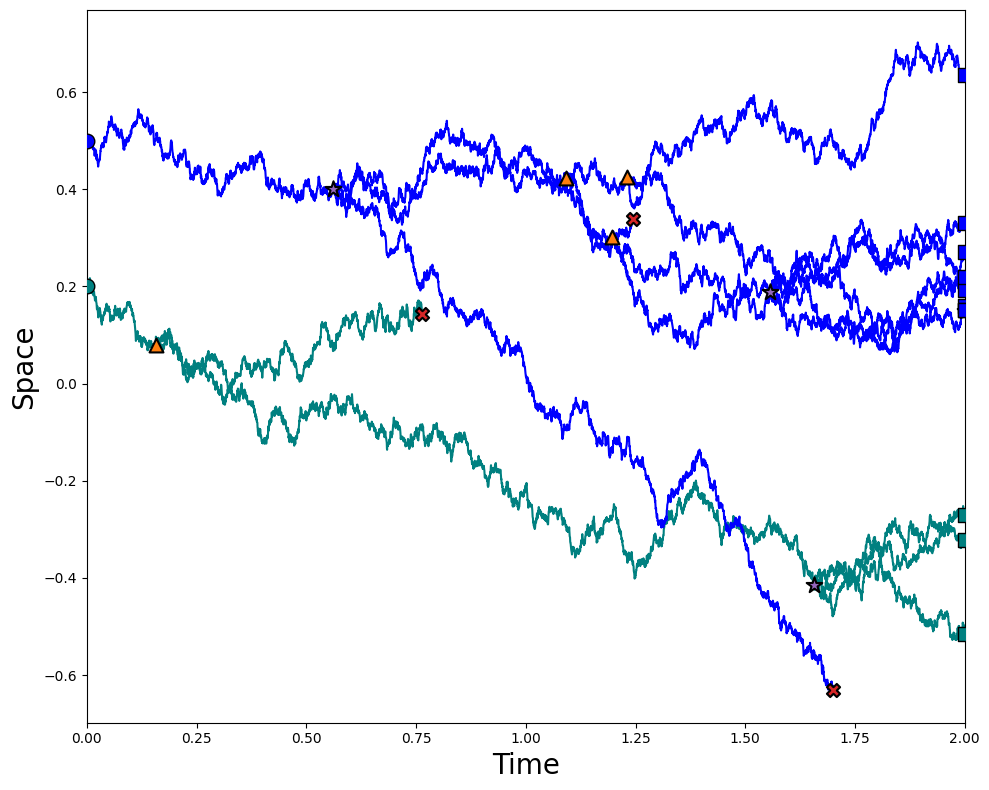

In [170]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass, field

# 可以注释掉下面这一行以获得完全随机的结果
# np.random.seed(4)

# --- 定义数据结构 (保持不变) ---
@dataclass
class Particle:
    id: int
    position_history: list[float] = field(default_factory=list)
    time_history: list[float] = field(default_factory=list)
    active: bool = True
    parent_id: int = None
    initial_ancestor_idx: int = 0 # 追踪它是哪条初始轨迹的后代

@dataclass
class BranchEvent:
    time: float
    position: float
    offspring_count: int # 0, 2, 或 3

# --- 模拟核心函数 (微调以支持多条初始轨迹追踪) ---
def simulate_stochastic_bbm(T, N, starting_positions, sigma, branching_rate):
    dt = T / N
    t_steps = np.linspace(0, T, N + 1)
    
    particles = []
    p_id_counter = 0
    
    # 初始化多条起始轨迹
    for i, y0 in enumerate(starting_positions):
        p = Particle(
            id=p_id_counter, 
            position_history=[y0], 
            time_history=[0.0], 
            initial_ancestor_idx=i # 标记祖先索引
        )
        particles.append(p)
        p_id_counter += 1
        
    events = []

    print(f"Simulation Starts with {len(starting_positions)} paths. Rate={branching_rate}")

    for i in range(1, N + 1):
        current_time = t_steps[i]
        new_particles_this_step = []
        particles_to_deactivate = []
        
        active_particles = [p for p in particles if p.active]
        if not active_particles and current_time > 0:break

        for p in active_particles:
            # 1. 扩散
            dW = np.random.randn() * np.sqrt(dt) * sigma
            new_pos = p.position_history[-1] + dW
            p.position_history.append(new_pos)
            p.time_history.append(current_time)
            
            # 2. 分支判定
            branch_prob = 1.0 - np.exp(-branching_rate * dt)
            
            if np.random.rand() < branch_prob:
                # 决定子代数量：0, 2, 3，概率各 1/3
                num_offspring = np.random.choice([0, 2, 3], p=[1/3, 1/3, 1/3])
                
                events.append(BranchEvent(current_time, new_pos, num_offspring))
                particles_to_deactivate.append(p.id)
                
                if num_offspring > 0:
                    for _ in range(num_offspring):
                        new_p = Particle(
                            id=p_id_counter,
                            position_history=[new_pos], 
                            time_history=[current_time],
                            parent_id=p.id,
                            initial_ancestor_idx=p.initial_ancestor_idx # 继承祖先索引
                        )
                        new_particles_this_step.append(new_p)
                        p_id_counter += 1

        for p in particles:
            if p.id in particles_to_deactivate: p.active = False
        particles.extend(new_particles_this_step)

    return particles, events

# ============================
# 参数设置
# ============================
T_end = 2.0
N_steps = 5000
sigma_val = 0.2
lambda_rate = 1.2
# --- 修改点 1: 设置2个起始位置 ---
start_pos = [0.5, 0.2] 

# ============================
# 运行模拟
# ============================
all_particles, all_events = simulate_stochastic_bbm(T_end, N_steps, start_pos, sigma_val, lambda_rate)

# ============================
# 绘图 visualization
# ============================
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

# --- 修改点 2: 绘制所有路径统一颜色 ---
# 为了区分两条初始轨迹的后代，我们可以用两种略微不同的蓝色
colors = ['blue', 'teal'] # 分别用于第一条和第二条起始轨迹的族群

for p in all_particles:
    # 根据祖先索引选择颜色
    path_color = colors[p.initial_ancestor_idx % len(colors)]
    # 所有路径使用相同的透明度和线宽，不再区分 active/inactive
    ax.plot(p.time_history, p.position_history, '-', color=path_color, linewidth=1.5, alpha=1, zorder=1)

# 2. 绘制事件标记 (保持不变)
styles = {
    0: {'marker': 'X', 'color': '#d62728', 's': 90, 'label': 'Death (0)'},
    2: {'marker': '^', 'color': '#ff7f0e', 's': 100, 'label': 'Split (2)'},
    3: {'marker': '*', 'color': '#9467bd', 's': 140, 'label': 'Split (3)'}
}
plotted_labels = set()
for event in all_events:
    style = styles[event.offspring_count]
    label = style['label'] if style['label'] not in plotted_labels else None
    ax.scatter(event.time, event.position, 
               marker=style['marker'], color=style['color'], s=style['s'], 
               edgecolor='k', linewidth=1.5, zorder=3, label=label)
    if label: plotted_labels.add(label)

# 3. 绘制起点和终点
# 起点
for i, y0 in enumerate(start_pos):
    label = 'Start Points' if i == 0 else None
    ax.scatter(0, y0, color=colors[i], marker='o', s=110, edgecolors='k', zorder=4, label=label)

# 终点 (活到最后的粒子)
active_at_end = [p for p in all_particles if p.active]
if active_at_end:
    final_time_actual = active_at_end[0].time_history[-1]
    for p in active_at_end:
        c = colors[p.initial_ancestor_idx % len(colors)]
        # 只给第一个终点加标签以避免图例重复
        label = 'Alive at Final Time' if p == active_at_end[0] else None
        ax.scatter(final_time_actual, p.position_history[-1], 
                   color=c, marker='s', s=110, edgecolors='k', zorder=4, label=label)

# 图表设置
ax.set_xlim(0, T_end)
# 动态设置Y轴范围
all_y = [y for p in all_particles for y in p.position_history]
if all_y:
    ymin, ymax = min(all_y), max(all_y)
    pad = (ymax - ymin) * 0.05
    ax.set_ylim(ymin - pad, ymax + pad)

ax.set_xlabel("Time", fontsize=20)
ax.set_ylabel("Space", fontsize=20)

plt.tight_layout()
plt.savefig("stochastic_bbm_multiple_starts.png", dpi=150)
plt.show()